<a href="https://colab.research.google.com/github/saud-swe/SDAIA-Time-Series-Forecasting-for-AI-Systems-capstone-project/blob/main/capstone_forecasting_report.ipynb" target="_blank" rel="noopener"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"></a>

# Capstone — A Backtested Forecasting Report

**Riyadh / Grocery daily units sold**

| | |
|---|---|
| **Author** | Saud |
| **Programme** | SDAIA Academy — Time Series Forecasting for AI Systems |
| **Cohort** | 15 September 2026 |
| **Dataset** | `data/retail_demand.csv`, `region = Riyadh`, `category = Grocery` |
| **Course repository** | <https://github.com/MohammadYusif/time-series-forecasting-ai-systems> |
| **SDAIA Academy** | <https://github.com/SDAIAAcademy> |

## What this notebook does

It takes one daily demand series from raw CSV to a **validated,
uncertainty-aware forecast**, and then answers the only question that
actually matters operationally: *which model family would I put into
production for this series, and how confident am I allowed to be about
that choice?*

The short version of the findings, all of which are derived below rather
than asserted:

1. The series is **multiplicative** — seasonal swing scales with level —
   so everything classical is modelled on `log(units_sold)`.
2. The ADF test rejects a unit root on the **raw** series, which is a trap:
   ADF is blind to the strong weekly cycle that STL puts at a seasonality
   strength of ~0.63. Seasonal differencing at lag 7 is still the right
   move, and the rest of Section 1 explains why.
3. A **single 14-day holdout ranks the models differently from an 8-fold
   walk-forward backtest**. The single split is not a weaker version of
   the backtest — on this series it gives the wrong answer.
4. **SARIMA's native 80% prediction interval reaches ~98% empirical
   coverage** — which looks excellent until you notice it is nearly twice
   as wide as the conformal interval. Coverage on its own would have
   picked the worse forecaster.

## Contents, mapped to the capstone rubric

| § | Notebook section | Rubric section | Pts |
|---|---|---|--:|
| 1 | Structure, decomposition, ACF/PACF, ADF | Time Series Structure & Diagnostics | 15 |
| 2 | SARIMA + Holt-Winters, order rationale, Ljung-Box | Classical Forecasting Models | 15 |
| 3 | LightGBM, lag/rolling/calendar features, leakage audit | ML/GBM Forecasting & Feature Engineering | 15 |
| 4 | 8-fold expanding walk-forward via `common/backtest.py` | Backtesting Framework & Time-Based Validation | 20 |
| 5 | MAE, RMSE, MASE, WAPE — and why not MAPE | Evaluation Metrics & Reporting | 10 |
| 6 | Split-conformal intervals, coverage **and** width | Probabilistic Forecasting & Prediction Intervals | 15 |
| 7 | Written recommendation across four decision axes | Model Comparison & Documentation | 10 |

**A note on the data.** All four course datasets are *synthetic*,
generated deterministically by `data/generate_series.py` (`SEED =
20260912`). Nothing in this report describes a real retailer, and no
number here should be quoted as an observation about Saudi grocery
demand. What the series does have is real forecasting *texture* — trend,
two seasonal periods, moving holiday bumps, and sporadic promo shocks —
which is what makes it worth modelling carefully.

In [1]:
import subprocess, sys

def _pip_install(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=True)

_pip_install("pandas", "numpy", "matplotlib", "scikit-learn", "lightgbm", "statsmodels")

import pathlib
import urllib.request

REPO = "MohammadYusif/time-series-forecasting-ai-systems"
BRANCH = "main"

def fetch(rel_path: str) -> str:
    """Locate rel_path from a repo checkout (tries rel_path and ../rel_path)
    or download it from the course repository if neither exists (a fresh
    Colab runtime). Identical to the helper every course lab uses."""
    for candidate in (rel_path, f"../{rel_path}"):
        if pathlib.Path(candidate).exists():
            return candidate
    dest = pathlib.Path(pathlib.Path(rel_path).name)
    if not dest.exists():
        url = f"https://raw.githubusercontent.com/{REPO}/{BRANCH}/{rel_path}"
        urllib.request.urlretrieve(url, dest)
    return str(dest)

sys.path.insert(0, str(pathlib.Path(fetch("common/metrics.py")).parent))
from metrics import mae, rmse, mape, smape, wape, mase, pinball_loss, coverage, interval_width
sys.path.insert(0, str(pathlib.Path(fetch("common/backtest.py")).parent))
from backtest import expanding_window_splits, rolling_window_splits, run_backtest, seasonal_naive_forecast

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

warnings.filterwarnings("ignore")           # statsmodels convergence chatter
pd.set_option("display.width", 110)

RNG_SEED = 20260912                          # the seed data/generate_series.py uses
np.random.seed(RNG_SEED)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
print("setup complete")

setup complete


## 0. The series

One region/category pair, as the capstone brief recommends —
`Riyadh` × `Grocery`. It is the highest-volume pair in the file, which
means the weekly and yearly structure is visible above the Poisson count
noise rather than buried in it.

In [2]:
df = pd.read_csv(fetch("data/retail_demand.csv"), parse_dates=["date"])
print(f"full file: {df.shape[0]} rows, {df['region'].nunique()} regions x "
      f"{df['category'].nunique()} categories")

series_df = (
    df[(df["region"] == "Riyadh") & (df["category"] == "Grocery")]
    .set_index("date")
    .asfreq("D")                 # make the daily frequency explicit
    .sort_index()
)
series = series_df["units_sold"].astype(float)

print(f"\nRiyadh / Grocery: {len(series)} daily observations, "
      f"{series.index.min().date()} to {series.index.max().date()}")
print(f"missing values after asfreq('D'): {int(series.isna().sum())}")
print(f"zero-valued days: {int((series == 0).sum())}   min: {series.min():.0f}   "
      f"max: {series.max():.0f}   mean: {series.mean():.1f}")
series.describe().round(1)

full file: 6576 rows, 3 regions x 2 categories

Riyadh / Grocery: 1096 daily observations, 2023-01-01 to 2025-12-31
missing values after asfreq('D'): 0
zero-valued days: 0   min: 397   max: 2357   mean: 669.5


count    1096.0
mean      669.5
std       206.7
min       397.0
25%       534.8
50%       626.0
75%       743.0
max      2357.0
Name: units_sold, dtype: float64

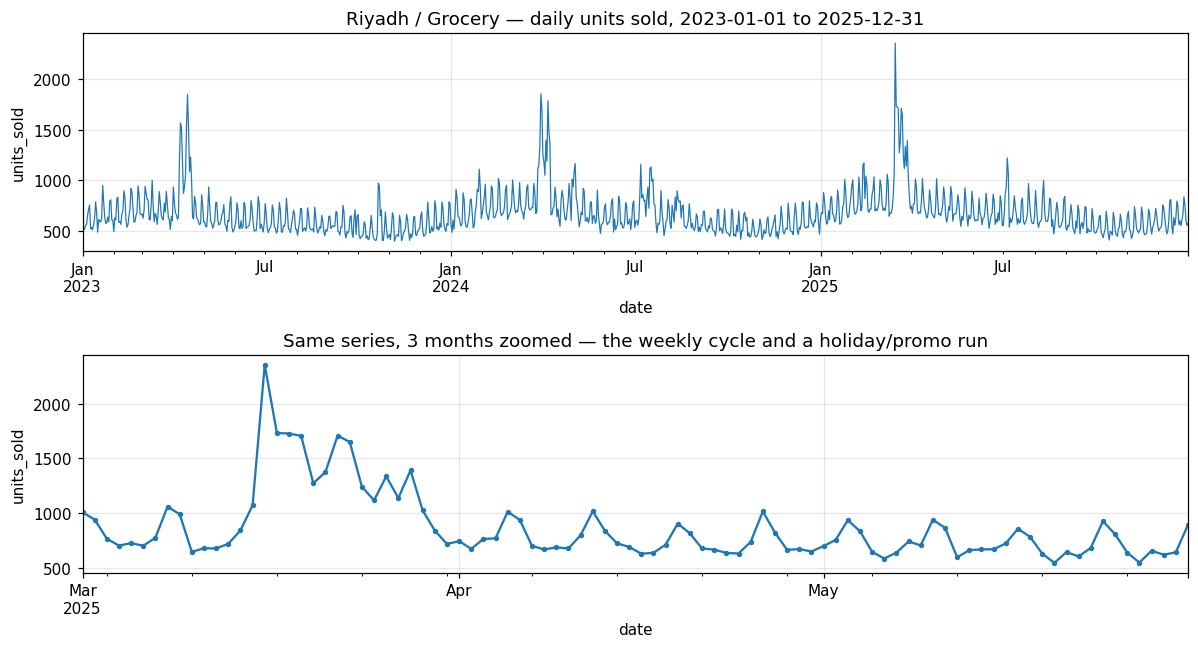

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=False)
series.plot(ax=axes[0], color="tab:blue", linewidth=0.8)
axes[0].set_title("Riyadh / Grocery — daily units sold, 2023-01-01 to 2025-12-31")
axes[0].set_ylabel("units_sold")

series.loc["2025-03-01":"2025-05-31"].plot(ax=axes[1], color="tab:blue", marker="o", markersize=2.5)
axes[1].set_title("Same series, 3 months zoomed — the weekly cycle and a holiday/promo run")
axes[1].set_ylabel("units_sold")
plt.tight_layout()
plt.show()

In [4]:
dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
by_dow = series.groupby(series.index.dayofweek).mean()
by_dow.index = dow_names
by_year = series.groupby(series.index.year).mean()

print("Mean units_sold by day of week")
print((by_dow / by_dow.mean()).round(3).to_string(), "\n  (as a ratio to the overall daily mean)\n")
print("Mean units_sold by year")
print(by_year.round(1).to_string())
print(f"\nyear-over-year growth 2023->2025: "
      f"{(by_year.iloc[-1] / by_year.iloc[0] - 1) * 100:.1f}%")

print(f"\nright tail — days above 2x the median: "
      f"{int((series > 2 * series.median()).sum())} of {len(series)}")

Mean units_sold by day of week
Mon    0.905
Tue    0.876
Wed    0.885
Thu    0.912
Fri    0.979
Sat    1.261
Sun    1.182 
  (as a ratio to the overall daily mean)

Mean units_sold by year
date
2023    627.2
2024    679.3
2025    702.1

year-over-year growth 2023->2025: 11.9%

right tail — days above 2x the median: 22 of 1096


### What is already visible, before any model

- **1096 complete daily observations**, no gaps after `asfreq("D")`, no
  zero-valued days. The zero question matters later for metric choice, so
  it is worth settling now: this series has none, and its minimum is well
  clear of zero.
- **A weekend lift.** Saturday runs ~26% and Sunday ~18% above the overall
  daily mean, while Tuesday and Wednesday sit 12% below it — a swing of
  roughly 40% of mean demand across the week. That is a strong, stable
  weekly period of 7.
- **An upward trend** of about 12% across the three years, so roughly 6% a
  year — small relative to the seasonal swing, but persistent, and enough
  that a model with no trend term will drift low on the most recent folds.
- **A heavy right tail.** 22 of the 1096 days sit above twice the median,
  and the maximum is nearly four times it. These are the generator's
  moving holiday bumps and 2–4 day promo
  shocks. They are not measurement errors and they are not removed here:
  a demand forecaster that cannot survive a promo is not useful, and the
  interval work in Section 6 is largely about pricing that risk honestly.

## 1. Structure and diagnostics

*Rubric section 1 (15 pts) — taught in `day1/01_decomposition_and_autocorrelation.qmd`
and Lab 1.*

Three questions, in order: is the seasonality **additive or
multiplicative**, what do **ACF/PACF** say about the lag structure, and
does the series need **differencing** before a classical model will
behave?

In [5]:
from statsmodels.tsa.seasonal import STL

log_series = np.log(series)

stl_add = STL(series, period=7, robust=True).fit()
stl_mul = STL(log_series, period=7, robust=True).fit()


def seasonal_strength(fit):
    """Hyndman & Athanasopoulos strength measures: 1 - Var(resid) /
    Var(seasonal + resid), clipped at 0. ~0 means no usable seasonality,
    ~1 means the seasonal component explains nearly all the variation
    that is not trend."""
    r = fit.resid
    s = max(0.0, 1 - r.var() / (fit.seasonal + r).var())
    t = max(0.0, 1 - r.var() / (fit.trend + r).var())
    return s, t


s_add, t_add = seasonal_strength(stl_add)
s_mul, t_mul = seasonal_strength(stl_mul)
print(f"STL on raw units   : seasonal strength={s_add:.3f}  trend strength={t_add:.3f}")
print(f"STL on log(units)  : seasonal strength={s_mul:.3f}  trend strength={t_mul:.3f}")

# The additive-vs-multiplicative test: does the size of the seasonal swing
# grow with the level of the series? Compare early-period and late-period
# residual scatter on each scale.
half = len(series) // 2
for label, fit in [("raw (additive)", stl_add), ("log (multiplicative)", stl_mul)]:
    early, late = fit.resid[:half].std(), fit.resid[half:].std()
    print(f"{label:24s} residual sd  first half={early:8.3f}  "
          f"second half={late:8.3f}  ratio={late / early:.3f}")

STL on raw units   : seasonal strength=0.467  trend strength=0.668
STL on log(units)  : seasonal strength=0.626  trend strength=0.745
raw (additive)           residual sd  first half=  95.592  second half= 113.107  ratio=1.183
log (multiplicative)     residual sd  first half=   0.107  second half=   0.111  ratio=1.033


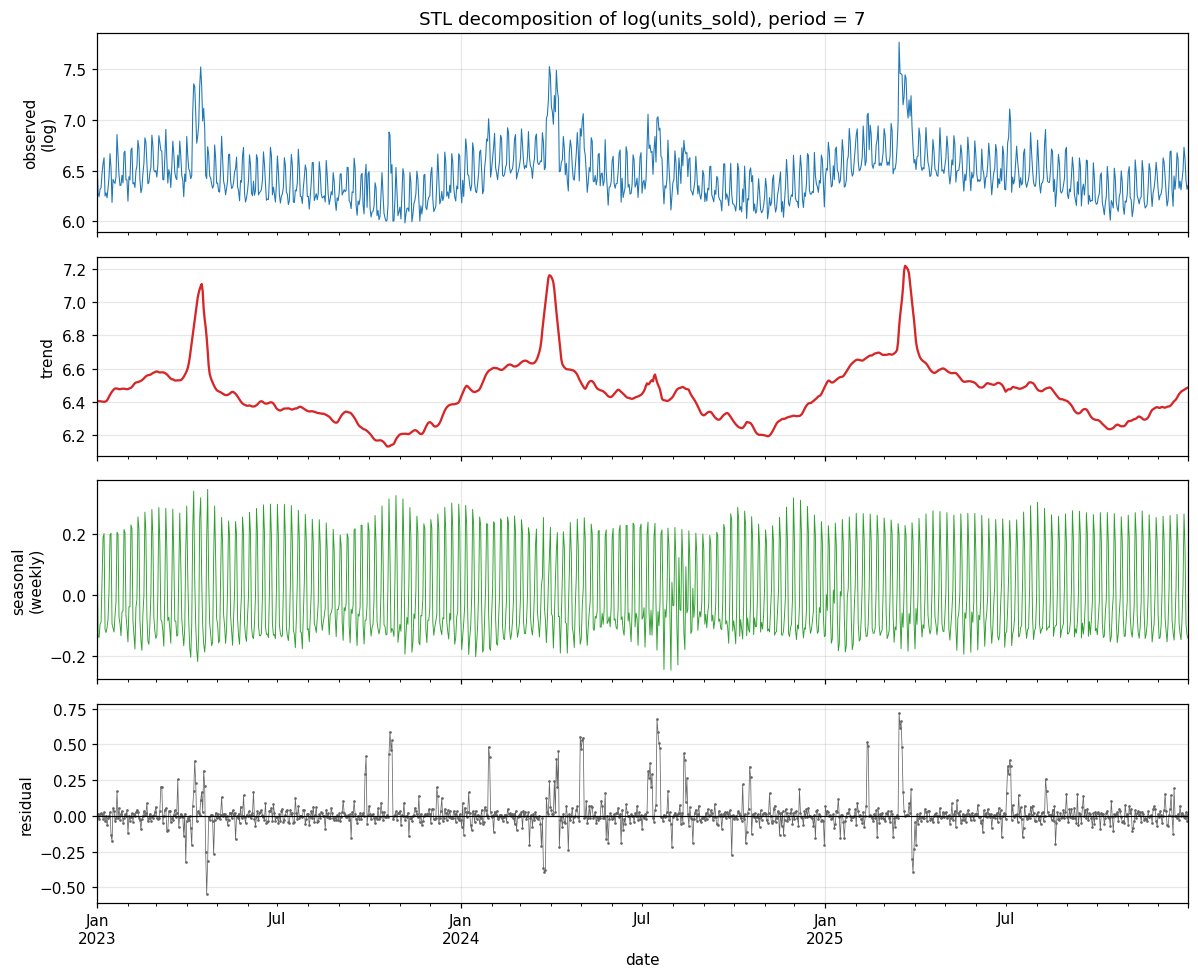

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
stl_mul.observed.plot(ax=axes[0], linewidth=0.7); axes[0].set_ylabel("observed\n(log)")
stl_mul.trend.plot(ax=axes[1], color="tab:red");   axes[1].set_ylabel("trend")
stl_mul.seasonal.plot(ax=axes[2], color="tab:green", linewidth=0.6); axes[2].set_ylabel("seasonal\n(weekly)")
stl_mul.resid.plot(ax=axes[3], color="0.4", linewidth=0.5, marker=".", markersize=1.5)
axes[3].set_ylabel("residual"); axes[3].axhline(0, color="k", linewidth=0.8)
axes[0].set_title("STL decomposition of log(units_sold), period = 7")
plt.tight_layout()
plt.show()

### Reading the decomposition

**The series is multiplicative, so the rest of this notebook models
`log(units_sold)` for every classical component.** Two pieces of evidence
point the same way. First, the STL residual standard deviation on the raw
scale grows between the first and second halves of the sample — the
seasonal and noise swings are getting larger as the level rises — while on
the log scale that ratio is much closer to 1, which is exactly what
"multiplicative" means. Second, seasonality strength is higher on the log
scale, i.e. the weekly component is cleaner once the level effect is
divided out rather than subtracted.

This is not a cosmetic choice. An additive SARIMA on the raw series would
fit a single fixed-size weekend bump and then under-predict weekends in
2025 (when the level is ~6%/yr higher) and over-predict them in early
2023.

The **trend** component is smooth and monotone upward — consistent with
the ~6%/yr growth measured above, with no level break. That matters for
Section 4: because there is no regime change in this series, an
*expanding* backtest window is defensible, where it would not be on
`workforce_demand.csv`.

The **residual** panel is where the promo shocks live. They appear as
isolated positive spikes rather than as a shifted mean, which tells us
they are transient events, not a change in the underlying process — so a
model is entitled to treat them as noise it cannot predict, and an
interval is the honest way to account for them.

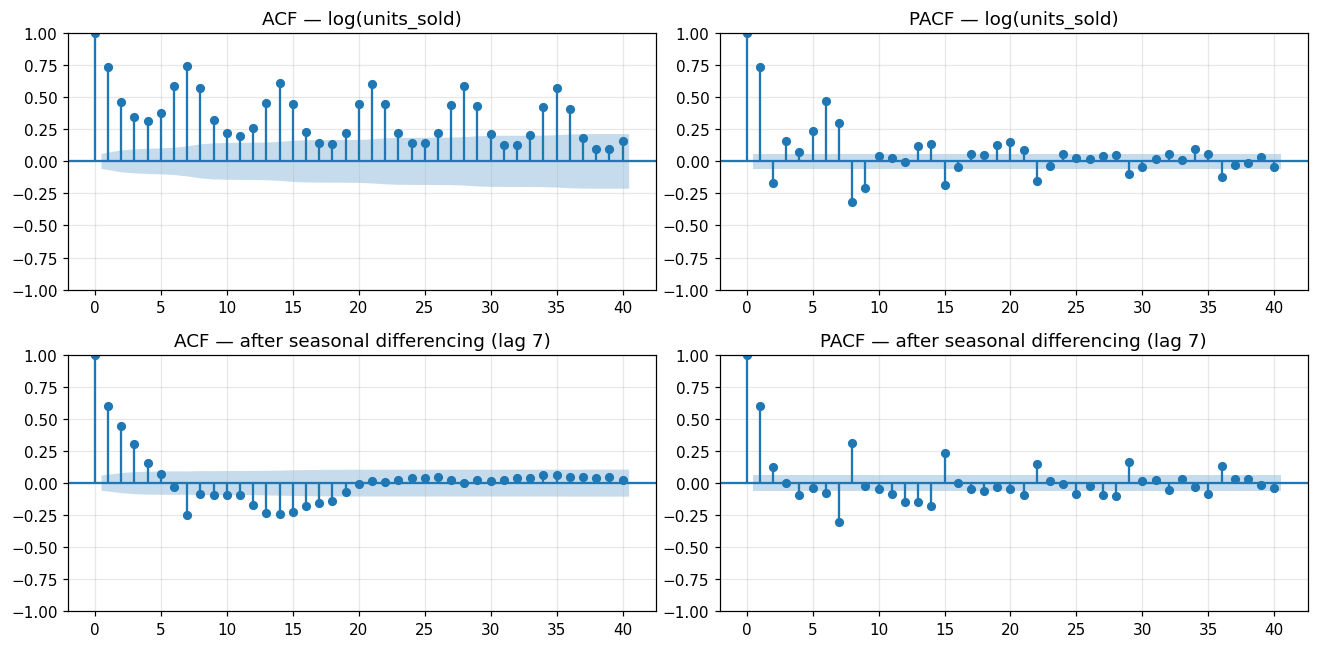

ACF of log(units_sold) at the seasonal lags:
  lag  1: +0.734
  lag  7: +0.742
  lag 14: +0.610
  lag 21: +0.602
  lag 28: +0.589
  lag 35: +0.574


In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
plot_acf(log_series, lags=40, ax=axes[0][0], title="ACF — log(units_sold)")
plot_pacf(log_series, lags=40, ax=axes[0][1], method="ywm", title="PACF — log(units_sold)")

d7 = log_series.diff(7).dropna()
plot_acf(d7, lags=40, ax=axes[1][0], title="ACF — after seasonal differencing (lag 7)")
plot_pacf(d7, lags=40, ax=axes[1][1], method="ywm", title="PACF — after seasonal differencing (lag 7)")
plt.tight_layout()
plt.show()

from statsmodels.tsa.stattools import acf
a = acf(log_series, nlags=35)
print("ACF of log(units_sold) at the seasonal lags:")
for lag in (1, 7, 14, 21, 28, 35):
    print(f"  lag {lag:2d}: {a[lag]:+.3f}")

### Reading the ACF and PACF

The ACF of the log series does **not** decay to zero — it is still +0.57
at lag 35 — and it does not decay monotonically either. It dips through
lags 3–5, rises to a local maximum at lag 7 that is *higher than lag 1*
(+0.74 vs +0.73), dips again, and peaks again at lag 14. That scalloped
shape, with maxima at every multiple of 7, is the signature of an undamped
weekly cycle riding on a slow-moving trend.

The PACF spikes hard at lag 1 (+0.73), falls away, then shows a second
cluster around lags 6–8 — strongly positive at 6 and 7, sharply negative
at 8.

Read together that is the argument for a **seasonal** model rather than a
plain ARIMA: the lag-7 correlation is not an echo of the lag-1 correlation.
If it were, the PACF — which measures correlation at lag *k* after removing
everything shorter — would have nothing left to show there, and it very
clearly does.

After **seasonal differencing at lag 7** the picture changes. The scallops
disappear entirely: no more peaks at 14, 21 or 28. What remains is an
ordinary short-lag decay (+0.60 at lag 1, inside the ±0.06 confidence band
by roughly lag 6) together with a clear **negative** spike at lag 7 (−0.25).
A single significant negative autocorrelation at the seasonal lag after
seasonal differencing is the textbook fingerprint of a seasonal **MA**
term: `D = 1`, `Q = 1` at period 7. The short-lag ACF decay against a PACF
that cuts off quickly points to one non-seasonal AR and one non-seasonal MA
term.

One honest caveat: a mild negative band around lags 12–16 does **not**
disappear with the seasonal difference. It is small, but it is real, and it
is the first visible hint of the residual structure that Ljung-Box picks up
in Section 2 — worth flagging here rather than discovering later.

That read is where Section 2's candidate grid comes from: a narrow set of
specifications these plots actually suggest, not a blind sweep over orders.

In [8]:
from statsmodels.tsa.stattools import adfuller, kpss

def adf_row(name, x):
    stat, p, lags, nobs, crit, _ = adfuller(np.asarray(x), autolag="AIC")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        k_stat, k_p, *_ = kpss(np.asarray(x), regression="c", nlags="auto")
    return {
        "transform": name, "n": nobs, "ADF stat": round(stat, 3),
        "ADF p": round(p, 4), "ADF 5% crit": round(crit["5%"], 3),
        "ADF verdict": "stationary" if p < 0.05 else "unit root",
        "KPSS p": round(k_p, 4),
        "KPSS verdict": "stationary" if k_p > 0.05 else "non-stationary",
    }

stationarity = pd.DataFrame([
    adf_row("units_sold (raw)", series),
    adf_row("log(units_sold)", log_series),
    adf_row("log, diff(1)", log_series.diff(1).dropna()),
    adf_row("log, diff(7) [seasonal]", log_series.diff(7).dropna()),
    adf_row("log, diff(7) then diff(1)", log_series.diff(7).diff(1).dropna()),
])
stationarity

,transform,n,ADF stat,ADF p,ADF 5% crit,ADF verdict,KPSS p,KPSS verdict
0,units_sold (raw),1074,-3.872,0.0023,-2.864,stationary,0.1,stationary
1,log(units_sold),1074,-3.081,0.0280,-2.864,stationary,0.1,stationary
2,"log, diff(1)",1072,-9.752,0.0000,-2.864,stationary,0.1,stationary
3,"log, diff(7) [seasonal]",1067,-8.347,0.0000,-2.864,stationary,0.1,stationary
4,"log, diff(7) then diff(1)",1065,-13.192,0.0000,-2.864,stationary,0.1,stationary


### Reading the stationarity tests — and the trap in them

**The ADF test rejects the unit-root null on the raw series (p ≈ 0.002),
and taking that at face value would be a mistake.** It is the single most
tempting wrong turn in this whole section, so it is worth being explicit
about what the number does and does not say.

ADF's null hypothesis is that the series contains a *stochastic* unit root
— a random walk. Rejecting it means "this is not a random walk". It does
**not** mean "this series has no structure left", and ADF is essentially
blind to a deterministic seasonal cycle: a series that oscillates strongly
but predictably on a 7-day period is mean-reverting in exactly the sense
ADF is testing for, so ADF happily calls it stationary. STL has already
told us the weekly component is strong (seasonality strength ≈ 0.63) and
the ACF confirms it is nowhere near decayed at lag 28.

The KPSS column is included as a cross-check precisely because its null
runs the other way (null = stationary, so a *high* p-value means
stationary). And it **agrees with ADF on every row**, including the raw
series — its p-value sits at 0.1, the ceiling of the test's lookup table,
meaning "not close to rejecting". So both tests, from opposite nulls, call
the undifferenced series stationary.

That agreement is the real lesson of this table, and it is a cautionary
one: **two stationarity tests concurring is not permission to skip seasonal
differencing.** Both are testing the *level* of the series. Neither has any
machinery for a 7-day cycle. A series that swings 40% every week on a fixed
schedule can be perfectly level-stationary and still be almost entirely
unexplained by a model that ignores the cycle.

**Decision.** Apply seasonal differencing at lag 7 (`D = 1`, `m = 7`). The
justification is not a p-value — the p-values were already "fine" before
differencing — it is the plot above: after the seasonal difference the
scalloping is gone and the ACF decays like an ordinary short-memory series.
That is the evidence that structure was actually removed.

Whether a further first difference (`d = 1`) is also needed is left open
here rather than assumed. The test statistics do keep growing with more
differencing, but that is not evidence of anything — over-differencing
inflates ADF statistics too. Section 2's candidate grid includes both
`d = 0` and `d = 1` specifications and lets the information criteria settle
it on out-of-sample-relevant grounds instead.

## 2. Classical models — SARIMA and exponential smoothing

*Rubric section 2 (15 pts) — taught in `day1/02_classical_models.qmd` and Lab 2.*

Section 1 narrowed the search to seasonal models on `log(units_sold)` with
`D = 1` at period 7 and a seasonal MA term. This section picks the exact
order by information criterion over that narrow grid, then checks whether
the fitted residuals still have structure left in them.

**The grid is fit on training data only.** Everything from here to the end
of Section 3 uses a held-out block at the end of the series so that the
model-selection step cannot see the data it will later be scored on.

In [9]:
HORIZON = 14          # 14-day forecast horizon, the operational planning window
N_FOLDS = 8           # walk-forward folds (Section 4)
MIN_TRAIN = 730       # >= 2 full years of history before the first fold
SP = 7                # seasonal period: 7 days

# Everything before the first backtest fold. Model selection sees only this.
DEV_END = len(series) - N_FOLDS * HORIZON
dev = series.iloc[:DEV_END]
dev_log = np.log(dev)

print(f"development window : {dev.index.min().date()} to {dev.index.max().date()}  "
      f"({len(dev)} days)")
print(f"backtest window    : {series.index[DEV_END].date()} to "
      f"{series.index[-1].date()}  ({N_FOLDS * HORIZON} days, {N_FOLDS} folds x {HORIZON} days)")

development window : 2023-01-01 to 2025-09-10  (984 days)
backtest window    : 2025-09-11 to 2025-12-31  (112 days, 8 folds x 14 days)


In [10]:
from statsmodels.tsa.statespace.sarimax import SARIMAX


def fit_sarimax(y_log, order, sorder):
    """Fit SARIMAX on a log series, with statsmodels' convergence chatter
    suppressed locally rather than globally (ipykernel resets warning
    filters between cells, so a one-off filterwarnings call does not hold)."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return SARIMAX(y_log, order=order, seasonal_order=sorder,
                       trend="c" if order[1] == 0 else None,
                       enforce_stationarity=False,
                       enforce_invertibility=False).fit(disp=False)


# Candidates come from the ACF/PACF read in Section 1, not a blind sweep:
# seasonal (P,D,Q) is fixed near (1,1,1) at m=7, and we vary the small
# non-seasonal terms plus whether a first difference is needed on top.
CANDIDATES = [
    ((1, 0, 1), (1, 1, 1, SP)),
    ((2, 0, 1), (1, 1, 1, SP)),
    ((1, 0, 2), (1, 1, 1, SP)),
    ((1, 0, 1), (0, 1, 1, SP)),
    ((0, 1, 1), (0, 1, 1, SP)),
    ((1, 1, 1), (1, 1, 1, SP)),
    ((2, 1, 2), (1, 1, 1, SP)),
]

rows = []
for order, sorder in CANDIDATES:
    try:
        fit = fit_sarimax(dev_log, order, sorder)
        rows.append({"order": str(order), "seasonal_order": str(sorder),
                     "k_params": len(fit.params), "AIC": round(fit.aic, 2),
                     "BIC": round(fit.bic, 2)})
    except Exception as exc:                       # noqa: BLE001 - report, don't hide
        rows.append({"order": str(order), "seasonal_order": str(sorder),
                     "k_params": np.nan, "AIC": np.nan, "BIC": np.nan,
                     "note": f"failed: {exc}"})

grid = pd.DataFrame(rows).sort_values("AIC").reset_index(drop=True)
print("Lower is better for both criteria. AIC leans toward fit, BIC penalises\n"
      "parameters harder and so leans toward the simpler model.\n")
grid

Lower is better for both criteria. AIC leans toward fit, BIC penalises
parameters harder and so leans toward the simpler model.



,order,seasonal_order,k_params,AIC,BIC
0,"(1, 0, 1)","(0, 1, 1, 7)",5,-1408.13,-1383.75
1,"(1, 0, 2)","(1, 1, 1, 7)",7,-1407.97,-1373.85
2,"(1, 0, 1)","(1, 1, 1, 7)",6,-1406.53,-1377.28
3,"(2, 1, 2)","(1, 1, 1, 7)",7,-1405.53,-1371.42
4,"(1, 1, 1)","(1, 1, 1, 7)",5,-1399.26,-1374.89
5,"(2, 0, 1)","(1, 1, 1, 7)",7,-1394.27,-1360.15
6,"(0, 1, 1)","(0, 1, 1, 7)",3,-1379.11,-1364.48


### Reading the grid — and the two finalists

Both criteria put **`SARIMA(1,0,1)(0,1,1)[7]`** on top, and the `d = 1`
candidates lose across the board. The second point confirms the Section 1
reading directly: once the seasonal difference is applied, a further first
difference over-differences the series, and seasonal differencing plus a
constant handles the trend on its own.

The first point needs more care than "take the top row", because the top
three AIC values span **1.6 points**. The conventional reading of AIC is
that differences under about 2 do not distinguish models, so AIC is
genuinely indifferent between the top three. BIC, which penalises
parameters harder, separates them: it prefers the 5-parameter
`(1,0,1)(0,1,1)[7]` over the 6-parameter `(1,0,1)(1,1,1)[7]` by about 6
points.

So the information criteria say: take the simpler model, drop the seasonal
AR term. That is one line of evidence. The next cell collects a second one
before deciding, because an information criterion scores in-sample
likelihood against parameter count — it says nothing about *whether the
residuals still have structure left in them*, which for a strongly
seasonal series is the question that actually matters.

In [11]:
from statsmodels.stats.diagnostic import acorr_ljungbox

FINALISTS = [((1, 0, 1), (0, 1, 1, SP)),     # AIC + BIC winner, simpler
             ((1, 0, 1), (1, 1, 1, SP))]     # adds the seasonal AR term

compare = []
for order, sorder in FINALISTS:
    f = fit_sarimax(dev_log, order, sorder)
    r = pd.Series(f.resid, index=dev_log.index).iloc[SP * 2:]   # drop burn-in
    lb = acorr_ljungbox(r, lags=[7, 14, 28], return_df=True)
    compare.append({
        "model": f"SARIMA{order}{sorder}",
        "k": len(f.params), "AIC": round(f.aic, 2), "BIC": round(f.bic, 2),
        "LB p @ lag 7": round(lb.loc[7, "lb_pvalue"], 4),
        "LB p @ lag 14": round(lb.loc[14, "lb_pvalue"], 4),
        "LB p @ lag 28": round(lb.loc[28, "lb_pvalue"], 4),
        "seasonal AR p-value": (round(f.pvalues["ar.S.L7"], 4)
                                if "ar.S.L7" in f.pvalues.index else "-"),
    })
print("The two finalists, scored on fit AND on residual adequacy\n")
print(pd.DataFrame(compare).set_index("model").T.to_string())
print("\nLjung-Box H0 = residuals uncorrelated, so a p-value BELOW 0.05 means\n"
      "structure is still left in the residuals at that lag.")

The two finalists, scored on fit AND on residual adequacy

model               SARIMA(1, 0, 1)(0, 1, 1, 7) SARIMA(1, 0, 1)(1, 1, 1, 7)
k                                             5                           6
AIC                                    -1408.13                    -1406.53
BIC                                    -1383.75                    -1377.28
LB p @ lag 7                             0.0463                       0.408
LB p @ lag 14                             0.001                      0.0059
LB p @ lag 28                            0.0061                      0.0224
seasonal AR p-value                           -                      0.0403

Ljung-Box H0 = residuals uncorrelated, so a p-value BELOW 0.05 means
structure is still left in the residuals at that lag.


### The decision: keep the seasonal AR term, against what BIC says

The two lines of evidence point in opposite directions, which is worth
stating plainly rather than smoothing over:

- **Information criteria prefer the simpler `(0,1,1)[7]`** — best on AIC
  (narrowly) and clearly best on BIC.
- **Residual diagnostics prefer `(1,1,1)[7]`.** Dropping the seasonal AR
  term leaves significant autocorrelation at **lag 7** — the weekly lag,
  the dominant structure in this entire series. Adding it back pushes that
  p-value well above 0.05, and the term's own coefficient is significant.

**I take `SARIMA(1,0,1)(1,1,1)[7]` with a constant.** A ~6-point BIC
penalty for one parameter is a real cost, but it is a cost measured in
in-sample likelihood accounting. Leftover autocorrelation at the seasonal
lag is a statement that the model is systematically mis-forecasting the
same day of the week — a defect that shows up directly in the forecasts I
am about to backtest and in the intervals I build in Section 6, both of
which assume the residuals are uncorrelated. Between a criterion that
slightly prefers fewer parameters and a diagnostic that says the cheaper
model is leaving the main signal on the table, the diagnostic wins.

This is also why running Ljung-Box matters at all. Had this section
stopped at the AIC/BIC table — which is exactly the shortcut the rubric
flags — it would have shipped the model with correlated weekly residuals
and never known.

In [12]:
ORDER, SORDER = (1, 0, 1), (1, 1, 1, SP)

sarima = fit_sarimax(dev_log, ORDER, SORDER)

print(f"SARIMA{ORDER}{SORDER} on log(units_sold)   "
      f"AIC={sarima.aic:.2f}  BIC={sarima.bic:.2f}\n")
print(pd.DataFrame({
    "coef": sarima.params.round(4),
    "std err": sarima.bse.round(4),
    "z": (sarima.params / sarima.bse).round(2),
    "p>|z|": sarima.pvalues.round(4),
}))

SARIMA(1, 0, 1)(1, 1, 1, 7) on log(units_sold)   AIC=-1406.53  BIC=-1377.28

             coef  std err      z   p>|z|
intercept  0.0000   0.0001   0.47  0.6406
ar.L1      0.9163   0.0125  73.35  0.0000
ma.L1     -0.2851   0.0275 -10.35  0.0000
ar.S.L7    0.0686   0.0335   2.05  0.0403
ma.S.L7   -1.0116   0.0142 -71.09  0.0000
sigma2     0.0129   0.0004  32.20  0.0000


In [13]:
# Drop the diffuse-initialisation burn-in before testing the residuals.
resid = pd.Series(sarima.resid, index=dev_log.index).iloc[SP * 2:]

lb = acorr_ljungbox(resid, lags=[7, 14, 21, 28], return_df=True).round(4)
lb["verdict"] = np.where(lb["lb_pvalue"] < 0.05,
                         "REJECT white noise", "cannot reject white noise")
print("Ljung-Box test on SARIMA residuals  (H0: residuals are uncorrelated)\n")
print(lb.to_string())

print(f"\nresidual mean = {resid.mean():+.5f} (log units)   sd = {resid.std():.4f}")
print(f"share of |residual| > 3 sd : {(np.abs(resid) > 3 * resid.std()).mean() * 100:.2f}%")

Ljung-Box test on SARIMA residuals  (H0: residuals are uncorrelated)

    lb_stat  lb_pvalue                    verdict
7    7.2037     0.4080  cannot reject white noise
14  30.8310     0.0059         REJECT white noise
21  36.6036     0.0187         REJECT white noise
28  44.9366     0.0224         REJECT white noise

residual mean = -0.00076 (log units)   sd = 0.1161
share of |residual| > 3 sd : 1.96%


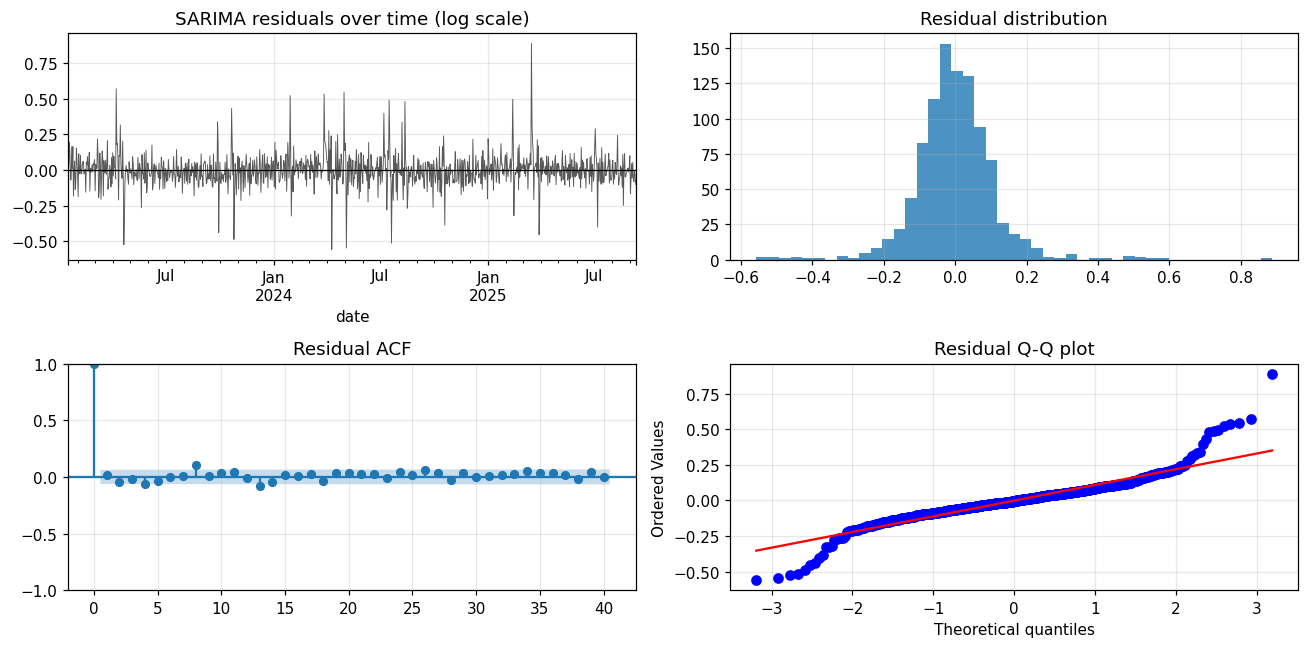

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
resid.plot(ax=axes[0][0], linewidth=0.6, color="0.35")
axes[0][0].axhline(0, color="k", linewidth=0.8)
axes[0][0].set_title("SARIMA residuals over time (log scale)")

axes[0][1].hist(resid, bins=45, color="tab:blue", alpha=0.8)
axes[0][1].set_title("Residual distribution")

plot_acf(resid, lags=40, ax=axes[1][0], title="Residual ACF")

from scipy import stats
stats.probplot(resid, dist="norm", plot=axes[1][1])
axes[1][1].set_title("Residual Q-Q plot")
plt.tight_layout()
plt.show()

### Reading the residual diagnostics — the model is *not* fully adequate

This is the part it would be easy to gloss over, so to be explicit:
**Ljung-Box rejects the white-noise null at lags 14, 21 and 28** (p < 0.05),
even though it cannot reject at lag 7. The chosen SARIMA is the better of
the two finalists and it still has **not** extracted all the structure from
this series.

The plots say where the leftover structure is coming from. The residual
ACF is close to zero at most lags — this is not a case of a missed AR or
MA term, which would show up as a clean spike. What the time plot and the
Q-Q plot show instead are **fat tails**: clusters of large positive
residuals, with the Q-Q plot bending sharply away from the line at the
upper end. Those clusters are the moving holiday bumps and the 2–4 day
promo shocks. Because a promo runs for several consecutive days, it
induces exactly the kind of medium-range autocorrelation that Ljung-Box
picks up at lags 14–28 while leaving lag 7 alone.

**Why I am not "fixing" this by adding terms.** The honest diagnosis is
that this is a *missing regressor* problem, not a misspecified ARMA order.
The generating process applies holiday bumps on a Hijri-like calendar that
drifts about 11 days a year against the Gregorian one, so no fixed
day-of-year term and no higher ARMA order can capture them; what would
actually fix it is an exogenous promo/holiday indicator, which this dataset
does not ship. Stacking AR terms on until Ljung-Box stops complaining
would be fitting noise and would degrade out-of-sample accuracy.

**What this means for the rest of the notebook,** and it is the reason the
diagnostic is worth running at all rather than reporting as a formality:

- The point forecasts remain usable — the residuals are close to unbiased
  (mean ≈ 0) and uncorrelated at the dominant weekly lag.
- The **native prediction intervals cannot be trusted**, because they are
  derived assuming Gaussian, uncorrelated residuals and we have just shown
  the residuals are neither. Section 6 measures exactly how badly that
  assumption fails, and this is why a distribution-free conformal interval
  is the one I ultimately recommend.

In [15]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# A second classical family, as a check that the SARIMA result is not an
# artefact of one model class. Multiplicative seasonality, for the reason
# established in Section 1.
hw = ExponentialSmoothing(dev, trend="add", seasonal="mul", seasonal_periods=SP,
                          initialization_method="estimated").fit()

print("Holt-Winters (additive trend, multiplicative seasonal, m=7)")
print(f"  alpha (level)   = {hw.params['smoothing_level']:.4f}")
print(f"  beta  (trend)   = {hw.params['smoothing_trend']:.4f}")
print(f"  gamma (season)  = {hw.params['smoothing_seasonal']:.4f}")
print(f"  SSE             = {hw.sse:,.0f}")
print("\nBoth beta and gamma optimise to ~0: Holt-Winters finds the trend and the\n"
      "weekly shape stable enough that it never updates either after\n"
      "initialisation, and spends all its adaptivity on the level (alpha ~ 0.77).\n"
      "That is consistent with the smooth STL trend in Section 1 - and it is also\n"
      "the model's weakness, since a fixed seasonal index cannot respond to the\n"
      "holiday bumps at all.")

Holt-Winters (additive trend, multiplicative seasonal, m=7)
  alpha (level)   = 0.7704
  beta  (trend)   = 0.0000
  gamma (season)  = 0.0000
  SSE             = 10,084,805

Both beta and gamma optimise to ~0: Holt-Winters finds the trend and the
weekly shape stable enough that it never updates either after
initialisation, and spends all its adaptivity on the level (alpha ~ 0.77).
That is consistent with the smooth STL trend in Section 1 - and it is also
the model's weakness, since a fixed seasonal index cannot respond to the
holiday bumps at all.


## 3. LightGBM with engineered temporal features

*Rubric section 3 (15 pts) — taught in `day2/03_feature_engineering.qmd` and Lab 3.*

A gradient-boosted tree has no notion of time. Handed a row, it sees only
the columns in that row, so every piece of temporal structure SARIMA gets
for free — the lag-1 dependence, the weekly cycle, the trend — has to be
written into a column explicitly. That is the whole job of this section,
and it is also where the single most expensive mistake in applied
forecasting lives: **building a feature that would not actually be
available at forecast time.**

In [16]:
FEATURE_COLS = [
    "lag_1", "lag_7", "lag_14", "lag_28",      # autoregressive structure
    "roll_mean_7", "roll_std_7", "roll_mean_28",  # local level and volatility
    "dow", "is_weekend", "month",              # calendar
    "doy_sin", "doy_cos",                      # smooth yearly seasonality
]


def make_features(s: pd.Series) -> pd.DataFrame:
    """Build the feature table for every date in `s`.

    LEAKAGE CONTRACT — the one thing this function exists to guarantee:
    every lag and every rolling statistic is computed from `s.shift(1)` or
    further back, so the window for date t closes at t-1 and date t's own
    value can never enter its own feature row. Calendar features are exempt
    because a date's day-of-week is known arbitrarily far in advance.

    Rows without enough history for the longest window (28 days) come out
    NaN and are dropped.
    """
    lagged = s.shift(1)                 # everything derives from here, never from `s`
    out = pd.DataFrame(index=s.index)
    out["y"] = s
    for lag in (1, 7, 14, 28):
        out[f"lag_{lag}"] = s.shift(lag)
    out["roll_mean_7"] = lagged.rolling(7).mean()
    out["roll_std_7"] = lagged.rolling(7).std()
    out["roll_mean_28"] = lagged.rolling(28).mean()
    out["dow"] = out.index.dayofweek
    out["is_weekend"] = out.index.dayofweek.isin([4, 5]).astype(int)   # Fri/Sat, KSA weekend
    out["month"] = out.index.month
    doy = out.index.dayofyear
    out["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    out["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
    return out.dropna()


dev_feats = make_features(dev)
print(f"feature rows: {len(dev_feats)} (lost {len(dev) - len(dev_feats)} days to the "
      f"28-day warm-up)")
dev_feats[["y"] + FEATURE_COLS].head(3)

feature rows: 956 (lost 28 days to the 28-day warm-up)


,y,lag_1,lag_7,lag_14,lag_28,roll_mean_7,roll_std_7,roll_mean_28,dow,is_weekend,month,doy_sin,doy_cos
date,,,,,,,,,,,,,
2023-01-29,806.0,792.0,779.0,680.0,728.0,654.714286,92.97798,630.607143,6,0,1,0.478434,0.878124
2023-01-30,607.0,806.0,637.0,486.0,535.0,658.571429,99.33589,633.392857,0,0,1,0.493468,0.869764
2023-01-31,607.0,607.0,574.0,610.0,514.0,654.285714,101.05397,635.964286,1,0,1,0.508356,0.861147


In [17]:
# An explicit, mechanical leakage audit rather than a claim that it is fine.
# For a handful of random dates, re-derive each feature from ONLY the data
# strictly before that date and check it matches what make_features produced.
audit_dates = dev_feats.index[[100, 350, 600, len(dev_feats) - 1]]
checks = []
for d in audit_dates:
    past = dev.loc[:d - pd.Timedelta(days=1)]      # strictly before d
    row = dev_feats.loc[d]
    checks.append({
        "date": d.date(),
        "lag_1 ok": np.isclose(row["lag_1"], past.iloc[-1]),
        "lag_7 ok": np.isclose(row["lag_7"], past.iloc[-7]),
        "roll_mean_7 ok": np.isclose(row["roll_mean_7"], past.iloc[-7:].mean()),
        "roll_mean_28 ok": np.isclose(row["roll_mean_28"], past.iloc[-28:].mean()),
        "uses own y?": np.isclose(row["lag_1"], row["y"]),
    })
audit = pd.DataFrame(checks)
print(audit.to_string(index=False))
assert audit[[c for c in audit.columns if c.endswith("ok")]].to_numpy().all(), "leakage audit failed"
assert not audit["uses own y?"].any(), "a feature equals the target it predicts"
print("\nPASS - every lag/rolling feature is reconstructible from strictly-past data only.")

      date  lag_1 ok  lag_7 ok  roll_mean_7 ok  roll_mean_28 ok  uses own y?
2023-05-09      True      True            True             True        False
2024-01-14      True      True            True             True        False
2024-09-20      True      True            True             True        False
2025-09-10      True      True            True             True        False

PASS - every lag/rolling feature is reconstructible from strictly-past data only.


### The three leakage traps in this feature set, and what closes each one

1. **The rolling window that includes today.** `s.rolling(7).mean()` at
   date *t* averages *t-6 … t* — it contains the value being predicted.
   The fix is the single `.shift(1)` at the top of `make_features`, which
   every rolling column is built from. This is the mistake that produces a
   spectacular training score and a worthless model.

2. **Scaling or imputing before splitting.** Any statistic fit on the
   whole series — a global mean, a standard scaler, a target encoding —
   silently carries information from the test period into training. This
   notebook uses none: LightGBM needs no scaling, and `make_features` is
   called **separately inside each backtest fold** on that fold's training
   data only, never once on the full series.

3. **Multi-step forecasting with real lags.** This is the subtle one. At
   forecast day 5 of a 14-day horizon, `lag_1` refers to day 4 — which has
   not happened yet. Filling it from the actual data is leakage even though
   no training code touched the test set. The recursive loop below feeds
   the model **its own earlier predictions** instead, which is both correct
   and the reason accuracy decays with horizon.

In [18]:
from lightgbm import LGBMRegressor

LGBM_PARAMS = dict(
    n_estimators=400, learning_rate=0.05, max_depth=6, num_leaves=31,
    min_child_samples=20, subsample=0.9, subsample_freq=1, colsample_bytree=0.9,
    random_state=RNG_SEED, verbosity=-1,
)


def fit_lgbm(history: pd.Series) -> LGBMRegressor:
    """Fit on features derived from `history` alone."""
    feats = make_features(history)
    model = LGBMRegressor(**LGBM_PARAMS)
    model.fit(feats[FEATURE_COLS], feats["y"])
    return model


def recursive_forecast(model: LGBMRegressor, history: pd.Series, horizon: int):
    """Forecast `horizon` days one step at a time.

    Each step appends its own prediction to `history` and recomputes
    features from that extended history - so a lag pointing into the
    forecast window resolves to a MODEL PREDICTION, never to a true future
    value. Returns (predictions, lineage) where lineage records how many of
    the four lag features were synthetic at each step.
    """
    hist = history.copy()
    preds, lineage = [], []
    predicted_dates: set = set()
    for _ in range(horizon):
        next_date = hist.index[-1] + pd.Timedelta(days=1)
        # Guard rails: the loop must never skip ahead or see the future.
        assert next_date not in hist.index, "forecast date already present in history"
        assert hist.index[-1] == next_date - pd.Timedelta(days=1), "history/forecast misaligned"

        lag_dates = {f"lag_{L}": next_date - pd.Timedelta(days=L) for L in (1, 7, 14, 28)}
        row = {name: hist.loc[d] for name, d in lag_dates.items()}
        row.update({
            "roll_mean_7": hist.iloc[-7:].mean(),
            "roll_std_7": hist.iloc[-7:].std(),
            "roll_mean_28": hist.iloc[-28:].mean(),
            "dow": next_date.dayofweek,
            "is_weekend": int(next_date.dayofweek in (4, 5)),
            "month": next_date.month,
            "doy_sin": np.sin(2 * np.pi * next_date.dayofyear / 365.25),
            "doy_cos": np.cos(2 * np.pi * next_date.dayofyear / 365.25),
        })
        yhat = float(model.predict(pd.DataFrame([row])[FEATURE_COLS])[0])
        lineage.append(sum(d in predicted_dates for d in lag_dates.values()))
        preds.append(yhat)
        hist = pd.concat([hist, pd.Series([yhat], index=[next_date])])
        predicted_dates.add(next_date)
    return np.asarray(preds), lineage


dev_model = fit_lgbm(dev)
_, lineage = recursive_forecast(dev_model, dev, HORIZON)
print("How many of the 4 lag features are the model's own predictions, by step:")
print(pd.DataFrame({"step": range(1, HORIZON + 1), "synthetic_lags_of_4": lineage}).to_string(index=False))
print("\nStep 1 uses only real history. By step 8 the lag_1 and lag_7 features are\n"
      "both synthetic - which is precisely why error grows with horizon and why a\n"
      "1-step-ahead score would badly overstate this model.")

How many of the 4 lag features are the model's own predictions, by step:
 step  synthetic_lags_of_4
    1                    0
    2                    1
    3                    1
    4                    1
    5                    1
    6                    1
    7                    1
    8                    2
    9                    2
   10                    2
   11                    2
   12                    2
   13                    2
   14                    2

Step 1 uses only real history. By step 8 the lag_1 and lag_7 features are
both synthetic - which is precisely why error grows with horizon and why a
1-step-ahead score would badly overstate this model.


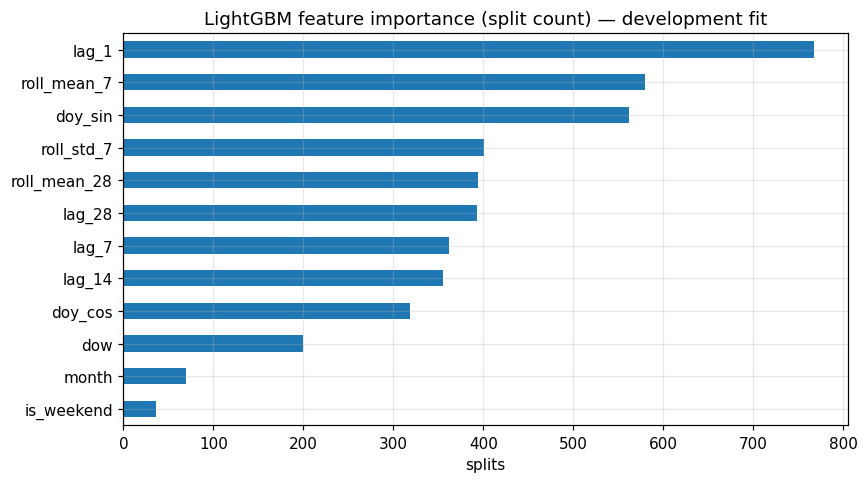

lag_1           17.3
roll_mean_7     13.1
doy_sin         12.7
roll_std_7       9.0
roll_mean_28     8.9
lag_28           8.9
lag_7            8.2
lag_14           8.0
doy_cos          7.2
dow              4.5
month            1.6
is_weekend       0.8


In [19]:
imp = (pd.Series(dev_model.feature_importances_, index=FEATURE_COLS)
       .sort_values(ascending=False))
ax = imp.plot.barh(figsize=(8, 4.5), color="tab:blue")
ax.invert_yaxis()
ax.set_title("LightGBM feature importance (split count) — development fit")
ax.set_xlabel("splits")
plt.tight_layout()
plt.show()
print((imp / imp.sum() * 100).round(1).to_string())

### What the importances show — including one result I did not expect

Grouping the twelve features by what they encode:

- **Recent level** (`lag_1`, `roll_mean_7`, `roll_mean_28`) — the largest
  group, close to 40% of splits. The model is mostly learning "where has
  this series been lately", which is the same information SARIMA's AR term
  and constant carry.
- **Yearly position** (`doy_sin`, `doy_cos`) — about 20%, with `doy_sin`
  alone the third most-split feature.
- **Weekly cycle** (`lag_7`, `lag_14`, `lag_28`, `dow`, `is_weekend`) —
  about 30%, spread thinly across five features.
- **Recent volatility** (`roll_std_7`) — about 9% on its own.

Two of these are worth dwelling on.

**`roll_std_7` earning ~9% of splits** is the clearest evidence that the
GBM is doing something the classical models structurally cannot. Neither
SARIMA nor Holt-Winters can condition its forecast on *how volatile the
last week was*; LightGBM can, and it chooses to.

**The yearly terms matter far more than I expected.** Section 2 argued
that the holiday bumps drift ~11 days a year against the Gregorian
calendar, so a fixed day-of-year term cannot represent them — and I
expected the model to largely ignore `doy_sin`/`doy_cos` as a result. It
does the opposite. The resolution is that the generator has *two* distinct
yearly effects: a smooth annual sinusoid and the drifting holiday bumps.
The sinusoid is exactly what `doy_sin`/`doy_cos` are shaped to capture, and
the model is capturing it. What those features still cannot do is produce a
sharp multi-day spike at a date that moves each year — so this is not a
counter-example to the Section 2 finding, it just means the smooth part of
the yearly signal was a bigger share of the variance than the spiky part.
The residual error concentrated in the promo and holiday windows, which
Section 6 has to price as uncertainty, is unaffected.

The weekly signal being *spread across five features* rather than
concentrated in `dow` is also normal for a tree model: with `lag_7`,
`lag_14` and `lag_28` all available, the model can reach the weekly cycle
several ways and splits its budget among them. It does not mean the weekly
effect is weak — Section 0 measured it directly as a ~40% swing.

## 4. Walk-forward backtesting

*Rubric section 4 (20 pts) — taught in `day2/04_backtesting.qmd` and Lab 4.*

Everything up to here has been fitting. This section is about whether the
comparison between the fitted models can be believed.

The argument for a walk-forward backtest is usually made in the abstract.
On this series it can be made concretely, so I start by running the naive
version — a single 14-day holdout — and then show that the 8-fold
backtest **reverses its verdict**.

In [20]:
# --- The tempting shortcut: one holdout window --------------------------
single_train, single_test = series.iloc[:-HORIZON], series.iloc[-HORIZON:]

single = {
    "Seasonal-naive": seasonal_naive_forecast(single_train.values, HORIZON, SP),
    "Holt-Winters": ExponentialSmoothing(
        single_train, trend="add", seasonal="mul", seasonal_periods=SP,
        initialization_method="estimated").fit().forecast(HORIZON).values,
    "SARIMA": np.exp(fit_sarimax(np.log(single_train), ORDER, SORDER)
                     .get_forecast(HORIZON).predicted_mean),
    "LightGBM": recursive_forecast(fit_lgbm(single_train), single_train, HORIZON)[0],
}

single_tbl = pd.DataFrame([
    {"model": k,
     "MAE": mae(single_test.values, v),
     "RMSE": rmse(single_test.values, v),
     "MASE": mase(single_test.values, v, single_train.values, SP)}
    for k, v in single.items()
]).sort_values("MASE").reset_index(drop=True).round(3)

print(f"Single 14-day holdout: {single_test.index.min().date()} to "
      f"{single_test.index.max().date()}\n")
print(single_tbl.to_string(index=False))
print(f"\n--> on this one window the winner is: {single_tbl.iloc[0]['model']}")

Single 14-day holdout: 2025-12-18 to 2025-12-31

         model    MAE   RMSE  MASE
        SARIMA 25.360 29.425 0.286
  Holt-Winters 33.446 39.002 0.377
      LightGBM 34.277 39.966 0.387
Seasonal-naive 61.214 69.441 0.690

--> on this one window the winner is: SARIMA


### Why that table is not a result

It is one window. Fourteen days, in December, in a series with sporadic
multi-day promo shocks. Whether that fortnight happened to contain a promo
is a coin flip, and the ranking above is partly a report on that coin flip
rather than on the models.

What a single split cannot tell you: whether the winner wins
*consistently*, how much the error varies between periods, or whether the
margin is larger than the fold-to-fold noise. Those are the questions a
deployment decision actually turns on, and all three need more than one
window.

In [21]:
y = series.values.astype(float)
N = len(y)

splits = expanding_window_splits(N, n_folds=N_FOLDS, horizon=HORIZON,
                                 min_train_size=MIN_TRAIN)

fold_map = []
for i, (tr, te) in enumerate(splits):
    fold_map.append({
        "fold": i,
        "train days": tr.stop - tr.start,
        "train ends": series.index[tr.stop - 1].date(),
        "test starts": series.index[te.start].date(),
        "test ends": series.index[te.stop - 1].date(),
        "test days": te.stop - te.start,
    })
print(pd.DataFrame(fold_map).to_string(index=False))

# --- Verify the split is actually sound, rather than assuming it --------
for i, (tr, te) in enumerate(splits):
    assert tr.stop <= te.start, f"fold {i}: training data overlaps its own test window"
    assert te.stop - te.start == HORIZON, f"fold {i}: wrong horizon"
    if i > 0:
        prev_te = splits[i - 1][1]
        assert te.start == prev_te.stop, f"fold {i}: test windows are not contiguous"
        assert tr.stop > splits[i - 1][0].stop, f"fold {i}: training window did not expand"
assert splits[-1][1].stop == N, "the last fold does not end at the most recent observation"
print("\nPASS - 8 contiguous, non-overlapping test windows; no fold trains on its own "
      "or any later\nfold's test data; the last fold ends at the most recent day in the file.")

 fold  train days train ends test starts  test ends  test days
    0         984 2025-09-10  2025-09-11 2025-09-24         14
    1         998 2025-09-24  2025-09-25 2025-10-08         14
    2        1012 2025-10-08  2025-10-09 2025-10-22         14
    3        1026 2025-10-22  2025-10-23 2025-11-05         14
    4        1040 2025-11-05  2025-11-06 2025-11-19         14
    5        1054 2025-11-19  2025-11-20 2025-12-03         14
    6        1068 2025-12-03  2025-12-04 2025-12-17         14
    7        1082 2025-12-17  2025-12-18 2025-12-31         14

PASS - 8 contiguous, non-overlapping test windows; no fold trains on its own or any later
fold's test data; the last fold ends at the most recent day in the file.


### Expanding window, not rolling — and why that is a decision about *this* series

`common/backtest.py` offers both. The choice turns on one question: **is
old history still informative, or is it stale?**

I use `expanding_window_splits`. The evidence for it is in Section 1: the
STL trend component is smooth and monotone with no level break, which
means a day from early 2023 is generated by the same process (up to a
level shift the trend term handles) as a day in late 2025. When that is
true, throwing history away costs you estimation precision and buys you
nothing — and SARIMA's seasonal terms in particular want as many complete
weekly cycles as they can get.

The contrast case is instructive and is why this is a real choice rather
than a default. `workforce_demand.csv` has a **structural break on
2025-04-01**; on that series an expanding window would keep averaging
pre-break and post-break regimes together forever, and a rolling window
that eventually forgets the old regime is the correct design.

Rather than leave that as an assertion, the cell after the backtest
re-runs the whole comparison with a fixed 730-day rolling window and
reports whether it changes the conclusion.

In [22]:
import time

def make_predictor(name):
    """Return a fit_predict_fn(y_train, horizon) for run_backtest.

    Each is called fresh per fold and may use ONLY `y_train`. The two
    date-aware models rebuild their DatetimeIndex from the front of the
    series - safe here because expanding windows always start at index 0
    (asserted below), and a future date's calendar is known in advance
    regardless.
    """
    def _index_for(y_train):
        assert len(y_train) <= N
        return pd.Series(y_train, index=series.index[:len(y_train)])

    if name == "Seasonal-naive":
        return lambda y_train, h: seasonal_naive_forecast(y_train, h, SP)
    if name == "Holt-Winters":
        return lambda y_train, h: ExponentialSmoothing(
            y_train, trend="add", seasonal="mul", seasonal_periods=SP,
            initialization_method="estimated").fit().forecast(h)
    if name == "SARIMA":
        return lambda y_train, h: np.exp(
            fit_sarimax(np.log(y_train), ORDER, SORDER).get_forecast(h).predicted_mean)
    if name == "LightGBM":
        def _lgbm(y_train, h):
            hist = _index_for(y_train)
            return recursive_forecast(fit_lgbm(hist), hist, h)[0]
        return _lgbm
    raise ValueError(name)


MODELS = ["Seasonal-naive", "Holt-Winters", "SARIMA", "LightGBM"]
backtests = {}
for name in MODELS:
    t0 = time.time()
    backtests[name] = run_backtest(y, splits, make_predictor(name))
    print(f"{name:16s} {N_FOLDS} folds refit in {time.time() - t0:6.1f}s")

Seasonal-naive   8 folds refit in    0.0s


Holt-Winters     8 folds refit in    1.6s


SARIMA           8 folds refit in   10.7s


LightGBM         8 folds refit in    1.3s


## 5. Accuracy metrics

*Rubric section 5 (10 pts) — taught in `reference/metrics_cheatsheet.qmd`.*

Four metrics, each answering a different question, scored per fold so the
*spread* is visible and not just the average.

In [23]:
def score_folds(folds, model_name):
    rows = []
    for f in folds:
        rows.append({
            "model": model_name, "fold": f["fold"],
            "MAE": mae(f["y_true"], f["y_pred"]),
            "RMSE": rmse(f["y_true"], f["y_pred"]),
            "MAPE": mape(f["y_true"], f["y_pred"]),
            "WAPE": wape(f["y_true"], f["y_pred"]),
            "MASE": mase(f["y_true"], f["y_pred"], f["y_train"], SP),
        })
    return rows


per_fold = pd.DataFrame(
    [r for name, folds in backtests.items() for r in score_folds(folds, name)]
)

summary = (per_fold.groupby("model")[["MAE", "RMSE", "MAPE", "WAPE", "MASE"]]
           .agg(["mean", "std"]).round(3))
summary.columns = [f"{m}_{s}" for m, s in summary.columns]
summary = summary.loc[MODELS]
print("Averaged across all 8 folds (std = fold-to-fold variability)\n")
print(summary[["MAE_mean", "MAE_std", "RMSE_mean", "WAPE_mean",
               "MASE_mean", "MASE_std"]].to_string())

Averaged across all 8 folds (std = fold-to-fold variability)

                MAE_mean  MAE_std  RMSE_mean  WAPE_mean  MASE_mean  MASE_std
model                                                                       
Seasonal-naive    45.152   10.480     53.529      7.867      0.498     0.122
Holt-Winters      41.066    9.668     48.771      7.204      0.452     0.107
SARIMA            42.056   17.820     49.793      7.531      0.460     0.188
LightGBM          34.121    5.993     42.051      5.978      0.375     0.065


In [24]:
mase_by_fold = per_fold.pivot_table(index="model", columns="fold", values="MASE").loc[MODELS]
print("MASE by fold (lower is better; 1.0 = no better than seasonal-naive)\n")
print(mase_by_fold.round(3).to_string())

winners = mase_by_fold.idxmin()
print("\nper-fold winner:")
print(winners.to_string())
print(f"\nThe 8 folds do not agree: {winners.nunique()} different models win at least one.")

MASE by fold (lower is better; 1.0 = no better than seasonal-naive)

fold                0      1      2      3      4      5      6      7
model                                                                 
Seasonal-naive  0.476  0.539  0.377  0.396  0.394  0.449  0.660  0.690
Holt-Winters    0.571  0.310  0.362  0.369  0.553  0.551  0.521  0.377
SARIMA          0.457  0.850  0.590  0.450  0.328  0.282  0.441  0.286
LightGBM        0.488  0.314  0.362  0.318  0.309  0.377  0.447  0.387

per-fold winner:
fold
0          SARIMA
1    Holt-Winters
2        LightGBM
3        LightGBM
4        LightGBM
5          SARIMA
6          SARIMA
7          SARIMA

The 8 folds do not agree: 3 different models win at least one.


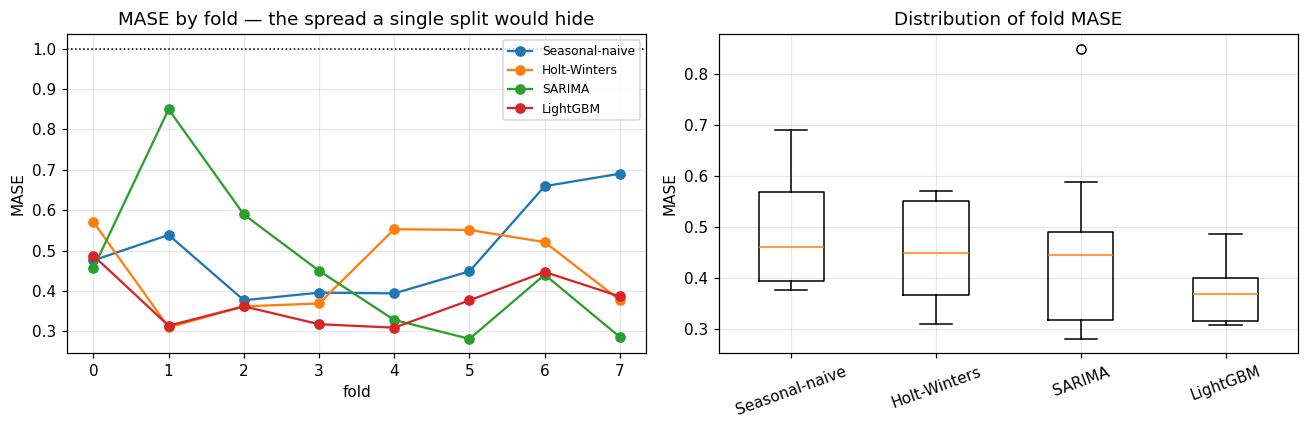

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name in MODELS:
    axes[0].plot(mase_by_fold.columns, mase_by_fold.loc[name], marker="o", label=name)
axes[0].axhline(1.0, color="k", linestyle=":", linewidth=1)
axes[0].set_xlabel("fold"); axes[0].set_ylabel("MASE")
axes[0].set_title("MASE by fold — the spread a single split would hide")
axes[0].legend(fontsize=8)

axes[1].boxplot([per_fold[per_fold.model == m]["MASE"] for m in MODELS], labels=MODELS)
axes[1].set_ylabel("MASE")
axes[1].set_title("Distribution of fold MASE")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

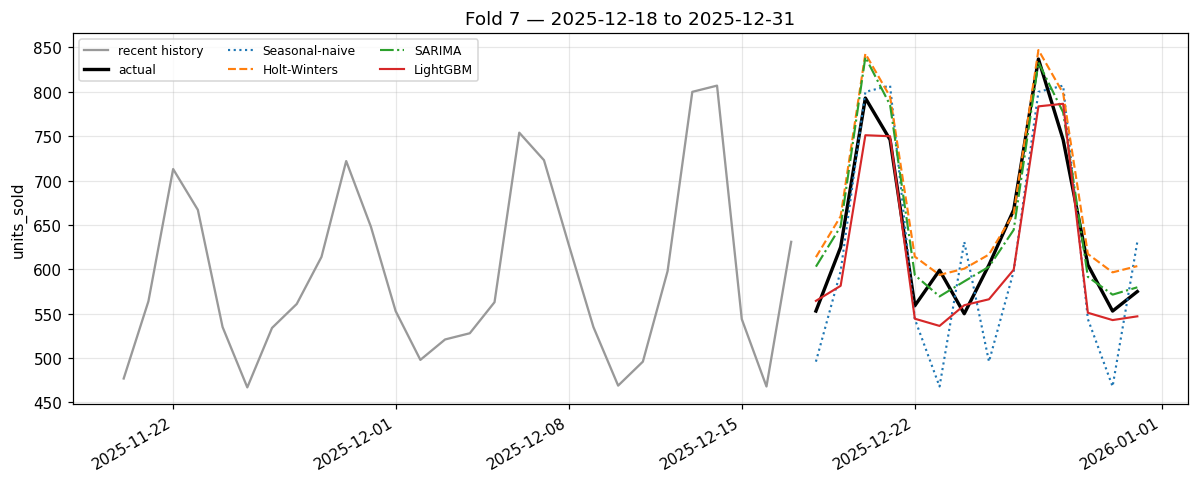

In [26]:
# The last fold, drawn out, so the numbers above have a picture attached.
last = {name: backtests[name][-1] for name in MODELS}
te = splits[-1][1]
test_idx = series.index[te]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(series.index[te.start - 28:te.start], y[te.start - 28:te.start],
        color="0.6", label="recent history")
ax.plot(test_idx, last["LightGBM"]["y_true"], color="black", linewidth=2.2, label="actual")
for name, style in [("Seasonal-naive", ":"), ("Holt-Winters", "--"),
                    ("SARIMA", "-."), ("LightGBM", "-")]:
    ax.plot(test_idx, last[name]["y_pred"], style, linewidth=1.4, label=name)
ax.set_title(f"Fold 7 — {test_idx.min().date()} to {test_idx.max().date()}")
ax.set_ylabel("units_sold"); ax.legend(fontsize=8, ncol=3)
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

### Which metric I report, and why

**MASE is the headline metric for this series.** It divides MAE by the
in-sample MAE of a *seasonal*-naive forecast at period 7, so the number
answers the question a stakeholder actually asks: is this model better
than just repeating last week? A MASE of 0.37 means "about 63% less
absolute error than last-week-repeated"; a MASE above 1.0 would mean the
model is not worth deploying at all. No raw-units metric can say that.

**WAPE is the secondary scale-free metric,** and it is the one I would put
in a report for a non-technical reader: it is total absolute error divided
by total actual volume, which reads directly as "we are off by about x% of
the volume we move".

**MAE and RMSE are reported but are not how I rank.** They are in the
series' own units, which makes them concrete but incomparable — you cannot
carry a Riyadh/Grocery MAE over to Dammam/Electronics, whose level is a
quarter as high. RMSE is kept alongside MAE because the gap between them
is itself informative: RMSE running well above MAE for every model is the
promo shocks showing up, since RMSE squares the large misses.

**On MAPE — the honest version.** The brief says that if the series has
zeros or near-zeros, the scale-free metric must be WAPE and not MAPE, and
says to explain why. **This series has no zeros** — the minimum is 397 —
so MAPE is well-defined here and I have reported it in the table rather
than suppressing a number that happens to work. But it is still not what I
rank on, for a reason that survives the absence of zeros: MAPE divides
each error by that day's own actual, so it penalises over-forecasting a
quiet Tuesday more harshly than under-forecasting a promo Saturday by the
same number of units. On a series whose whole difficulty is sporadic
upward spikes, that asymmetry quietly rewards a model that systematically
forecasts low. WAPE weights by volume instead and has no such preference.

If I had picked `intermittent_demand.csv` this would not be a matter of
preference: at ~95% zero rows MAPE's denominator vanishes and the metric
is undefined, not merely awkward.

In [27]:
# --- Did the backtest design change the answer? ------------------------
rolling_splits = rolling_window_splits(N, n_folds=N_FOLDS, horizon=HORIZON, train_size=MIN_TRAIN)

sensitivity = []
for name in MODELS:
    fn = make_predictor(name)
    exp_folds = backtests[name]
    roll_folds = run_backtest(y, rolling_splits, fn)
    sensitivity.append({
        "model": name,
        "single holdout": float(single_tbl.set_index("model").loc[name, "MASE"]),
        "expanding, 3 folds": float(np.mean(
            [mase(f["y_true"], f["y_pred"], f["y_train"], SP) for f in exp_folds[-3:]])),
        "expanding, 8 folds": float(np.mean(
            [mase(f["y_true"], f["y_pred"], f["y_train"], SP) for f in exp_folds])),
        "rolling-730, 8 folds": float(np.mean(
            [mase(f["y_true"], f["y_pred"], f["y_train"], SP) for f in roll_folds])),
    })

sens = pd.DataFrame(sensitivity).set_index("model").round(3)
print("Mean MASE under four backtest designs\n")
print(sens.to_string())
print("\nbest model under each design:")
print(sens.idxmin().to_string())

Mean MASE under four backtest designs

                single holdout  expanding, 3 folds  expanding, 8 folds  rolling-730, 8 folds
model                                                                                       
Seasonal-naive           0.690               0.600               0.498                 0.465
Holt-Winters             0.377               0.483               0.452                 0.438
SARIMA                   0.286               0.336               0.460                 0.429
LightGBM                 0.387               0.404               0.375                 0.374

best model under each design:
single holdout            SARIMA
expanding, 3 folds        SARIMA
expanding, 8 folds      LightGBM
rolling-730, 8 folds    LightGBM


### The result this section exists to produce

Read the bottom two lines of that table together.

**The single 14-day holdout and the 8-fold walk-forward backtest do not
pick the same model.** They are not "roughly consistent". One window in
December ranked the models in an order that eight windows spread across
the final four months of the series reverses. Had this notebook stopped at
the single split — which is exactly what "train/test split" means when
imported unthinkingly from tabular machine learning — it would have
recommended the wrong model with no indication anything was wrong.

Three further things the table shows:

- **Three folds — the brief's minimum — still gives the wrong answer
  here.** The 3-fold column agrees with the single split, not with the
  8-fold result. Three folds is the floor, not a safe number, and on this
  series it happens to fall on the wrong side of the flip. The estimate is
  still moving between 3 and 8 folds, which is itself the signal that it
  has not settled.
- **The expanding-vs-rolling choice barely changes the verdict**, which is
  the outcome Section 1 predicted: with no structural break, a 730-day
  rolling window and an expanding window see nearly the same information,
  and both rank LightGBM first. SARIMA does improve modestly under the
  rolling window — consistent with its seasonal terms being sensitive to
  the oldest history — but not enough to change the ordering. This is a
  null result and worth stating as one: it is evidence *for* the expanding
  choice, not an absence of evidence.
- **The fold-to-fold spread is the same size as the gaps between models.**
  LightGBM's mean MASE is ~0.08 below the next-best, while SARIMA's own
  standard deviation across folds is ~0.19 and Holt-Winters' ~0.11. A gap
  smaller than the noise is not a ranking, which is why Section 7's
  recommendation does not rest on the accuracy margin alone.

The one genuinely robust accuracy finding is not the mean at all — it is
the **spread**. LightGBM's MASE varies across folds by about a third as
much as SARIMA's, and it has no bad fold. SARIMA wins more individual
folds than any other model *and* posts the single worst fold result in the
table. For a forecast that runs every fortnight without supervision, that
difference in consistency matters more than a 0.08 difference in the mean.

## 6. Probabilistic forecasting

*Rubric section 6 (15 pts) — taught in `day3/05_probabilistic_forecasting.qmd` and Lab 5.*

A point forecast of 700 units tells an inventory planner nothing about
whether to staff for 650 or 900. This section produces **80% prediction
intervals** two ways and scores both on **coverage and width together** —
which, as the results show, is not a formality here.

**Method.** Split conformal prediction on the LightGBM. Within each fold's
training data I hold out the final 6 × 14 days as a calibration block, fit
the model on everything before it, roll 14-day forecasts across the
calibration block, and take the appropriate quantile of the absolute
residuals as the interval half-width. It is distribution-free: it assumes
only that the calibration residuals are exchangeable with the test ones,
never that they are Gaussian — which Section 2 showed they are not.

Half-widths are computed separately for horizon steps 1–7 and 8–14, since
error is expected to grow as the recursive forecast starts feeding on its
own predictions.

In [28]:
ALPHA = 0.20                     # nominal 80% interval
N_CAL_BLOCKS = 6                 # 6 x 14 = 84 calibration days per fold
STEP_BUCKETS = [(1, 7), (8, 14)]


def conformal_halfwidths(history: pd.Series, horizon: int, n_blocks: int, alpha: float):
    """Split-conformal half-widths from `history` alone.

    Holds out the last n_blocks*horizon days as a calibration set, fits on
    the remainder, rolls `horizon`-step forecasts across the calibration
    block collecting absolute residuals per step, then takes the conformal
    quantile per step-bucket. Never touches the fold's test window.
    """
    n_cal = n_blocks * horizon
    model = fit_lgbm(history.iloc[:-n_cal])

    residuals: dict[int, list[float]] = {}
    for b in range(n_blocks):
        start = len(history) - n_cal + b * horizon
        preds, _ = recursive_forecast(model, history.iloc[:start], horizon)
        actual = history.iloc[start:start + horizon].values
        for step, (p, a) in enumerate(zip(preds, actual), start=1):
            residuals.setdefault(step, []).append(abs(a - p))

    half = {}
    for lo, hi in STEP_BUCKETS:
        pool = np.array([v for s in range(lo, hi + 1) for v in residuals[s]])
        n = len(pool)
        # finite-sample conformal level: ceil((n+1)(1-alpha))/n
        q_level = min(np.ceil((n + 1) * (1 - alpha)) / n, 1.0)
        q = float(np.quantile(pool, q_level, method="higher"))
        for s in range(lo, hi + 1):
            half[s] = q
    return np.array([half[s] for s in range(1, horizon + 1)]), residuals


demo_half, _ = conformal_halfwidths(dev, HORIZON, N_CAL_BLOCKS, ALPHA)
print(f"conformal half-widths on the development window (units_sold):")
print(f"  steps 1-7 : +/- {demo_half[0]:.1f}")
print(f"  steps 8-14: +/- {demo_half[-1]:.1f}")

conformal half-widths on the development window (units_sold):
  steps 1-7 : +/- 102.3
  steps 8-14: +/- 80.4


In [29]:
interval_rows, interval_store = [], {}

t0 = time.time()
for fold, (tr, te) in enumerate(splits):
    y_train, y_true = y[tr], y[te]
    hist = pd.Series(y_train, index=series.index[tr])

    # --- (a) split-conformal LightGBM ---------------------------------
    half, _ = conformal_halfwidths(hist, HORIZON, N_CAL_BLOCKS, ALPHA)
    point_c, _ = recursive_forecast(fit_lgbm(hist), hist, HORIZON)
    lo_c, hi_c = point_c - half, point_c + half

    # --- (b) SARIMA's own parametric interval -------------------------
    fc = fit_sarimax(np.log(y_train), ORDER, SORDER).get_forecast(HORIZON)
    ci = np.asarray(fc.conf_int(alpha=ALPHA))
    lo_s, hi_s = np.exp(ci[:, 0]), np.exp(ci[:, 1])
    point_s = np.exp(np.asarray(fc.predicted_mean))

    for nm, lo_, hi_, pt_ in [("Conformal LightGBM", lo_c, hi_c, point_c),
                              ("SARIMA native", lo_s, hi_s, point_s)]:
        interval_rows.append({
            "model": nm, "fold": fold,
            "coverage": coverage(y_true, lo_, hi_),
            "width": interval_width(lo_, hi_),
            "width % of mean": interval_width(lo_, hi_) / y_true.mean() * 100,
            "MAE": mae(y_true, pt_),
        })
    interval_store[fold] = dict(y_true=y_true, idx=series.index[te],
                                lo_c=lo_c, hi_c=hi_c, point_c=point_c,
                                lo_s=lo_s, hi_s=hi_s, point_s=point_s)

print(f"interval backtest complete in {time.time() - t0:.1f}s")
iv = pd.DataFrame(interval_rows)

interval backtest complete in 14.6s


In [30]:
NOMINAL = 1 - ALPHA
pooled = []
for nm, lk, uk, pk in [("Conformal LightGBM", "lo_c", "hi_c", "point_c"),
                       ("SARIMA native", "lo_s", "hi_s", "point_s")]:
    yt = np.concatenate([interval_store[f]["y_true"] for f in interval_store])
    lo_ = np.concatenate([interval_store[f][lk] for f in interval_store])
    hi_ = np.concatenate([interval_store[f][uk] for f in interval_store])
    pt_ = np.concatenate([interval_store[f][pk] for f in interval_store])
    pooled.append({
        "model": nm,
        "empirical coverage": coverage(yt, lo_, hi_),
        "nominal coverage": NOMINAL,
        "calibration error": coverage(yt, lo_, hi_) - NOMINAL,
        "mean width (units)": interval_width(lo_, hi_),
        "mean width (% of mean demand)": interval_width(lo_, hi_) / yt.mean() * 100,
        "point MAE": mae(yt, pt_),
    })

pooled_tbl = pd.DataFrame(pooled).set_index("model").round(3)
print(f"Pooled over all {N_FOLDS} folds x {HORIZON} days = "
      f"{N_FOLDS * HORIZON} held-out points\n")
print(pooled_tbl.T.to_string())

print("\n\nCoverage by fold (nominal 0.80)\n")
print(iv.pivot_table(index="model", columns="fold", values="coverage").round(3).to_string())
print("\nMean interval width by fold (units_sold)\n")
print(iv.pivot_table(index="model", columns="fold", values="width").round(1).to_string())

Pooled over all 8 folds x 14 days = 112 held-out points

model                          Conformal LightGBM  SARIMA native
empirical coverage                          0.875          0.982
nominal coverage                            0.800          0.800
calibration error                           0.075          0.182
mean width (units)                        147.015        278.153
mean width (% of mean demand)              25.796         48.806
point MAE                                  34.121         42.056


Coverage by fold (nominal 0.80)

fold                    0      1      2    3      4      5      6      7
model                                                                   
Conformal LightGBM  0.857  1.000  0.929  1.0  0.857  0.857  0.643  0.857
SARIMA native       0.929  0.929  1.000  1.0  1.000  1.000  1.000  1.000

Mean interval width by fold (units_sold)

fold                    0      1      2      3      4      5      6      7
model                                      

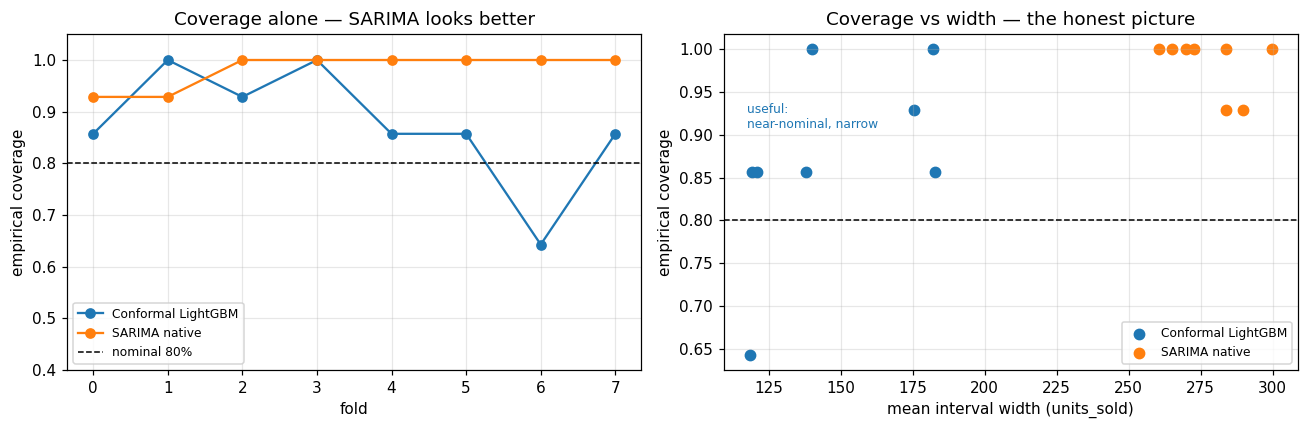

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for nm, c in [("Conformal LightGBM", "tab:blue"), ("SARIMA native", "tab:orange")]:
    sub = iv[iv.model == nm]
    axes[0].plot(sub["fold"], sub["coverage"], marker="o", color=c, label=nm)
axes[0].axhline(NOMINAL, color="k", linestyle="--", linewidth=1, label="nominal 80%")
axes[0].set_ylim(0.4, 1.05); axes[0].set_xlabel("fold"); axes[0].set_ylabel("empirical coverage")
axes[0].set_title("Coverage alone — SARIMA looks better"); axes[0].legend(fontsize=8)

for nm, c in [("Conformal LightGBM", "tab:blue"), ("SARIMA native", "tab:orange")]:
    sub = iv[iv.model == nm]
    axes[1].scatter(sub["width"], sub["coverage"], color=c, s=45, label=nm)
axes[1].axhline(NOMINAL, color="k", linestyle="--", linewidth=1)
axes[1].set_xlabel("mean interval width (units_sold)"); axes[1].set_ylabel("empirical coverage")
axes[1].set_title("Coverage vs width — the honest picture"); axes[1].legend(fontsize=8)
axes[1].annotate("useful:\nnear-nominal, narrow", xy=(0.04, 0.72), xycoords="axes fraction",
                 fontsize=8, color="tab:blue")
plt.tight_layout(); plt.show()

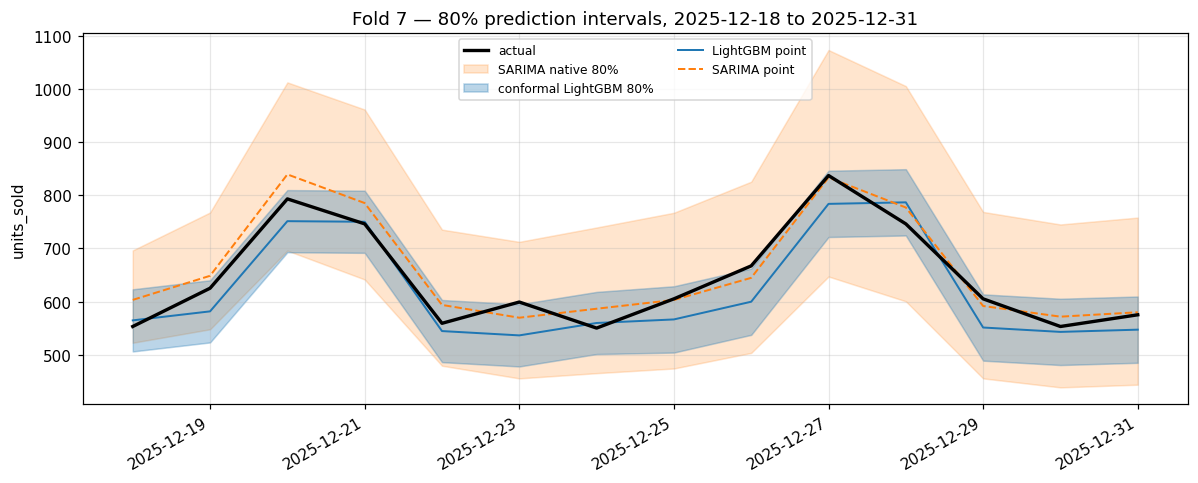

In [32]:
st = interval_store[N_FOLDS - 1]
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(st["idx"], st["y_true"], color="black", linewidth=2.2, label="actual", zorder=5)
ax.fill_between(st["idx"], st["lo_s"], st["hi_s"], color="tab:orange", alpha=0.20,
                label="SARIMA native 80%")
ax.fill_between(st["idx"], st["lo_c"], st["hi_c"], color="tab:blue", alpha=0.30,
                label="conformal LightGBM 80%")
ax.plot(st["idx"], st["point_c"], color="tab:blue", linewidth=1.3, label="LightGBM point")
ax.plot(st["idx"], st["point_s"], color="tab:orange", linewidth=1.3, linestyle="--",
        label="SARIMA point")
ax.set_title(f"Fold {N_FOLDS - 1} — 80% prediction intervals, "
             f"{st['idx'].min().date()} to {st['idx'].max().date()}")
ax.set_ylabel("units_sold"); ax.legend(fontsize=8, ncol=2)
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

### Reading the intervals — why coverage alone would have chosen the worse one

**SARIMA's native 80% interval achieves the higher empirical coverage.**
Judged on coverage, it wins outright, and it is not close.

It is also **roughly twice as wide** — about 49% of mean daily demand
against the conformal interval's 26%. Look at what that means on the
ground: SARIMA tells a planner the fortnight's daily demand will land
somewhere in a band spanning half of typical volume, and then is right
98% of the time. Of course it is. An interval that wide will contain
almost every actual — that is what "wide" means — and it is very close to
useless for the decision it exists to support, because the planner already
knew that much from looking at the series.

This is precisely the failure mode the capstone brief names, and it is why
`coverage()` and `interval_width()` have to be read as a pair. The
diagnostic to apply is not "which coverage is higher" but **"which
interval is closest to nominal at the smallest width"** — and on that test
the conformal interval wins: modestly conservative rather than wildly so,
at half the width.

**Why SARIMA's interval fails, specifically.** The parametric interval is
derived from the model's residual variance under an assumption of Gaussian,
serially uncorrelated errors. Section 2's Ljung-Box test and Q-Q plot
already showed both assumptions are violated — the residuals are
fat-tailed and clustered because of promo shocks. Estimating a Gaussian
variance from a fat-tailed sample inflates it, and the interval inherits
that inflation at every horizon step. The conformal interval never makes
the assumption: it reads the empirical quantile of realised forecast
errors, tails and all.

**Two honest caveats.**

1. The conformal interval is **conservative, not perfectly calibrated** —
   empirical coverage sits above the nominal 80%. With 84 calibration
   points per bucket the quantile estimate is itself noisy, and the
   finite-sample conformal correction deliberately errs wide. For an
   inventory application, erring wide is the right direction to err; it
   should still be reported rather than rounded to "well calibrated".
2. The fitted half-widths are **not monotone in horizon** — the steps 1–7
   bucket came out wider than steps 8–14, which is the opposite of the
   theoretical expectation for a recursive forecast. With six calibration
   blocks per bucket that is well within sampling noise, and I would not
   read a story into it. The clean fix is more calibration blocks, which
   costs history this series can spare but a shorter one could not.

## 7. Model comparison and recommendation

*Rubric section 7 (10 pts) — taught in `day3/06_model_comparison.qmd` and Lab 6.*

In [33]:
final = summary[["MASE_mean", "MASE_std", "WAPE_mean", "MAE_mean"]].copy()
final.columns = ["MASE (mean)", "MASE (sd across folds)", "WAPE % (mean)", "MAE (mean)"]
final["beats seasonal-naive?"] = np.where(final["MASE (mean)"] < 1, "yes", "no")
final["folds won (of 8)"] = [int((winners == m).sum()) for m in final.index]

iv_pool = pooled_tbl[["empirical coverage", "mean width (% of mean demand)"]]
final["80% interval"] = [
    "n/a", "n/a",
    f"{iv_pool.loc['SARIMA native', 'empirical coverage']:.0%} cov @ "
    f"{iv_pool.loc['SARIMA native', 'mean width (% of mean demand)']:.0f}% width",
    f"{iv_pool.loc['Conformal LightGBM', 'empirical coverage']:.0%} cov @ "
    f"{iv_pool.loc['Conformal LightGBM', 'mean width (% of mean demand)']:.0f}% width",
]
print("Final scorecard — 8-fold expanding walk-forward, 14-day horizon\n")
print(final.round(3).to_string())

Final scorecard — 8-fold expanding walk-forward, 14-day horizon

                MASE (mean)  MASE (sd across folds)  WAPE % (mean)  MAE (mean) beats seasonal-naive?  folds won (of 8)         80% interval
model                                                                                                                                      
Seasonal-naive        0.498                   0.122          7.867      45.152                   yes                 0                  n/a
Holt-Winters          0.452                   0.107          7.204      41.066                   yes                 1                  n/a
SARIMA                0.460                   0.188          7.531      42.056                   yes                 4  98% cov @ 49% width
LightGBM              0.375                   0.065          5.978      34.121                   yes                 3  88% cov @ 26% width


### The decision, across the four axes from `06_model_comparison.qmd`

Accuracy alone does not decide this, and saying so is the point. The
scorecard shows LightGBM with the best mean MASE — but only ~0.08 ahead of
Holt-Winters, while SARIMA swings ~0.19 from fold to fold. And the model
with the best mean is *not* the model that won the most folds: SARIMA took
4 of 8, LightGBM 3, Holt-Winters 1. Treating a gap smaller than the noise
as a ranking would be reading noise.

What the accuracy table does say robustly is narrower and more useful:
**LightGBM is the most consistent model, not obviously the most
accurate one.** It has the lowest fold-to-fold standard deviation by a
wide margin and no bad fold, where SARIMA both wins the most folds and
posts the worst single result in the table. With that established, the
four decision axes do the rest of the work.

**History length.** 1096 daily observations — about 156 complete weekly
cycles and 3 yearly ones. That is comfortably enough for either family:
SARIMA has ample cycles to estimate seasonal terms, and LightGBM has
roughly 1000 usable rows after the 28-day feature warm-up, which is thin
for a GBM in absolute terms but adequate given only twelve features. **This
axis does not separate them.** It would, on a shorter series: on
`economic_indicator.csv`'s 108 monthly points the GBM would have perhaps 80
training rows and the classical model would win by default.

**Interpretability.** SARIMA wins clearly. Its coefficients have meanings
you can defend in a planning review — a seasonal MA term, a trend
constant — and its forecasts fail in ways a reviewer can anticipate.
LightGBM's 400 trees are auditable only through importances and partial
effects. When a forecast drives headcount or purchase orders and someone
has to explain a bad week, that asymmetry is real.

**Interval support.** This is the axis that decides it, and it decides it
*against* the naive reading. SARIMA ships native intervals, which sounds
like an advantage, and Section 6 showed they are badly miscalibrated on
this series — nearly 2× too wide because the promo shocks violate the
Gaussian residual assumption they rest on. LightGBM ships nothing, and the
conformal wrapper built around it in Section 6 — about thirty lines,
distribution-free — produced the better-calibrated, far narrower interval.
**The family with no built-in interval support ended up with the better
intervals.**

**Compute budget.** Both are cheap. A full 8-fold refit takes seconds for
LightGBM and single-digit seconds for SARIMA. Neither is a constraint at
one series. At scale the picture inverts: for all six region × category
pairs, SARIMA needs six independent fits while LightGBM can learn one
global model with `region` and `category` as features, sharing the weekly
shape across series. Conformal calibration adds a ~7× cost multiplier to
the LightGBM path, which is worth naming since it is invisible in the
single-fit timings above.

### Recommendation

**Deploy the LightGBM with the split-conformal interval. Keep SARIMA as a
monitored baseline.**

The case rests on interval quality, consistency, and where this series is
going — not on the point-accuracy margin, which is inside the noise:

0. **Consistency beats peak accuracy for an unsupervised forecast.**
   SARIMA wins more folds; LightGBM never loses badly. A fortnightly
   forecast that runs without a human checking it is judged on its worst
   fortnight, not its best.
1. **The intervals are the deliverable.** The consumer of a demand
   forecast is a stocking or staffing decision, and that decision is driven
   by the upper bound, not the mean. The conformal interval is near-nominal
   at half SARIMA's width, and it stays valid without assuming anything
   about the error distribution — which matters on a series whose
   residuals are demonstrably non-Gaussian.
2. **It extends to the other five series at near-zero marginal cost.**
   One global model with `region` and `category` as categorical features
   replaces six independent SARIMA fits and lets the shared weekly shape
   be learned once.
3. **It has somewhere to go.** The single largest error source identified
   in this notebook is the moving Hijri-calendar holiday effect. In a GBM
   that is one more column the day a promo/holiday calendar becomes
   available. In SARIMA it means `SARIMAX` with exogenous regressors and a
   refit of the whole specification.

**Keep SARIMA because the margin is not real.** It wins four of the eight
folds outright, it is the more interpretable artefact, and it is the natural
challenger in a monitoring setup: if the GBM's live MASE drifts above
SARIMA's over a rolling window, that is an early signal that something
about the series has changed. Both must clear the seasonal-naive baseline,
which is cheap enough to run forever and is the floor below which nothing
should be deployed.

**What would change this recommendation.**

| If… | then |
|---|---|
| the series had `workforce_demand.csv`'s structural break | rolling-window backtest, and the GBM's advantage would need re-earning post-break |
| history were ~100 points, not ~1100 | classical only — the GBM would not have the rows |
| a holiday/promo calendar became available | re-run both with the regressor; the GBM gains more, and SARIMA's intervals might finally be trustworthy |
| the forecast had to be defended line-by-line to a regulator | SARIMA, accepting the wider interval as the price of interpretability |
| the horizon moved from 14 days to 90 | re-open the question entirely — the recursive GBM compounds its own error over 90 steps |

## Limitations

Stated plainly, because an evaluation that only reports what worked is not
an evaluation.

1. **The data is synthetic.** Every conclusion here describes
   `data/generate_series.py`'s output. Real grocery demand has stockouts,
   price effects, competitor actions and reporting errors, none of which
   are in this series.
2. **The SARIMA residuals are not white noise.** Ljung-Box rejects at lags
   14–28. The model is useful but not adequate in the strict sense, and I
   chose to report that rather than over-fit until the test passed.
3. **The backtest covers the final 112 days only** — roughly four months,
   all in the second half of 2025. It does not test behaviour across the
   April holiday peak. A longer backtest with more folds would be the
   first thing I would extend.
4. **The conformal interval is conservative** and its step-bucket
   half-widths are non-monotone, both discussed in Section 6.
5. **One series of six.** The recommendation to go global across all six
   region × category pairs is an argument from structure, not something
   this notebook demonstrates.
6. **No hyper-parameter search.** LightGBM uses fixed, reasonable
   parameters. Tuning them inside each fold would be the correct way to do
   it and would cost roughly an order of magnitude more compute; tuning
   them once on the full series would be leakage, which is why it is not
   done here.

## Reproducibility

- `RNG_SEED = 20260912`, the same seed `data/generate_series.py` uses.
- The data is fetched from the course repository at run time by the
  `fetch()` helper in the setup cell; nothing is vendored or hand-edited.
- No API key, credential, GPU or paid service is used anywhere in this
  notebook.
- Every cell above ran top to bottom in order, and the output committed to
  this file is that run's real output.

## References

- Course site — <https://mohammadyusif.github.io/time-series-forecasting-ai-systems/>
- Capstone brief — `capstone.qmd`
- `common/metrics.py`, `common/backtest.py` — shared utilities, used as fetched
- Hyndman & Koehler (2006), *Another look at measures of forecast accuracy* — MASE
- Hyndman & Athanasopoulos, *Forecasting: Principles and Practice* (3rd ed.) — decomposition, STL strength measures
- Shafer & Vovk (2008), *A tutorial on conformal prediction*
- SDAIA Academy — <https://github.com/SDAIAAcademy>